# Домашнее задание: Метрики и функции потерь в регрессии

## Тема
Реализация и анализ базового цикла решения задачи регрессии на табличных данных.

## Выбранный набор данных
**Auto MPG** (`scikit-learn/auto-mpg`)

Целевая переменная: **mpg** — расход топлива автомобиля в милях на галлон.

## Цель работы
В работе необходимо:
- корректно разделить данные на train / validation / test без утечек;
- реализовать предобработку внутри `Pipeline`;
- сравнить бейзлайны и обучаемые модели;
- рассчитать метрики MAE, RMSE, R²;
- сравнить модели с разными функциями потерь;
- выполнить финальную проверку лучшей модели на тестовой выборке.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, QuantileRegressor, HuberRegressor

In [2]:
df = load_dataset("scikit-learn/auto-mpg")["train"].to_pandas()
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
print("Размер датасета:", df.shape)
print()
print(df.info())
print()
print("Пропуски:")
print(df.isna().sum())

Размер датасета: (398, 9)

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 35.3 KB
None

Пропуски:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


## Описание набора данных

В работе используется набор данных **Auto MPG**.  
Он содержит характеристики автомобилей и целевую переменную `mpg`, отражающую топливную эффективность.

Это задача **регрессии**, так как требуется предсказать числовое значение.

Перед обучением необходимо:
- отделить целевую переменную;
- разделить выборку на train / validation / test в отношении 60 / 20 / 20;
- выполнить предобработку без утечек данных, то есть только внутри `Pipeline`.

Исходный набор данных был разделен на три части:

- обучающая выборка — 60%;
- валидационная выборка — 20%;
- тестовая выборка — 20%.

Разделение выполнялось с фиксированным `random_state=42`, что делает результаты воспроизводимыми.

Чтобы избежать утечек данных, вся предобработка была реализована внутри `Pipeline`.  
Для числовых признаков использовались заполнение пропусков медианой и масштабирование.  
Для категориальных признаков применялись заполнение наиболее частым значением и one-hot-кодирование.

In [4]:
data = df.copy()

target_col = "mpg"

X = data.drop(columns=[target_col])
y = data[target_col]

# Разбиение 60 / 20 / 20
# Сначала 80 / 20
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Затем 60 / 20 из исходного датасета
# 0.25 от 80% = 20% от полного датасета
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (238, 8) (238,)
Validation: (80, 8) (80,)
Test: (80, 8) (80,)


In [5]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Числовые признаки: ['cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']
Категориальные признаки: ['horsepower', 'car name']


In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [7]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def evaluate_model(model_name, model, X_train, y_train, X_eval, y_eval):
    model.fit(X_train, y_train)
    pred = model.predict(X_eval)
    metrics = regression_metrics(y_eval, pred)
    return {
        "Model": model_name,
        **metrics
    }, pred

## Подготовка данных и отсутствие утечек

Для исключения утечек данных вся предобработка выполняется внутри `Pipeline`:

- пропуски в числовых признаках заполняются медианой;
- числовые признаки масштабируются;
- категориальные признаки кодируются через one-hot encoding.

Это важно, потому что параметры преобразований должны вычисляться только на обучающей выборке и затем применяться к validation и test.

In [8]:
results = []

baseline_mean = DummyRegressor(strategy="mean")
baseline_median = DummyRegressor(strategy="median")

baseline_mean.fit(X_train, y_train)
baseline_median.fit(X_train, y_train)

pred_baseline_mean = baseline_mean.predict(X_val)
pred_baseline_median = baseline_median.predict(X_val)

results.append({
    "Model": "Baseline Mean",
    **regression_metrics(y_val, pred_baseline_mean)
})

results.append({
    "Model": "Baseline Median",
    **regression_metrics(y_val, pred_baseline_median)
})

pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Baseline Mean,7.234727,8.728830,-0.025648
1,Baseline Median,7.288750,8.971817,-0.083545


## Бейзлайн-модели

В качестве базовых моделей рассматриваются два константных предсказателя:

1. `Baseline Mean` — всегда предсказывает среднее значение `y_train`;
2. `Baseline Median` — всегда предсказывает медиану `y_train`.

Эти модели не используют признаки объектов и нужны как ориентир: обучаемая модель должна показывать качество лучше, чем наивное постоянное предсказание.

In [9]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_row, pred_val_linear = evaluate_model(
    "LinearRegression (MSE / OLS)",
    linear_model,
    X_train, y_train,
    X_val, y_val
)
results.append(linear_row)

pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Baseline Mean,7.234727,8.728830,-0.025648
1,Baseline Median,7.288750,8.971817,-0.083545
2,LinearRegression (MSE / OLS),5.612800,7.295298,0.283572


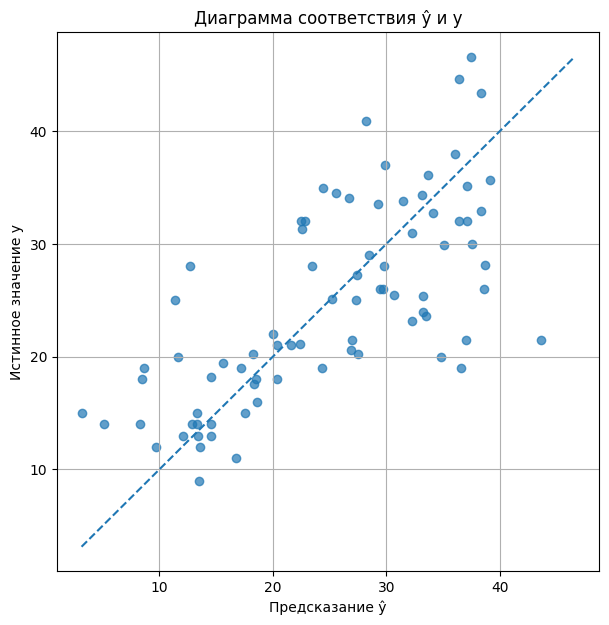

In [10]:
plt.figure(figsize=(7, 7))
plt.scatter(pred_val_linear, y_val, alpha=0.7)

line_min = min(pred_val_linear.min(), y_val.min())
line_max = max(pred_val_linear.max(), y_val.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.xlabel("Предсказание ŷ")
plt.ylabel("Истинное значение y")
plt.title("Диаграмма соответствия ŷ и y")
plt.grid(True)
plt.show()

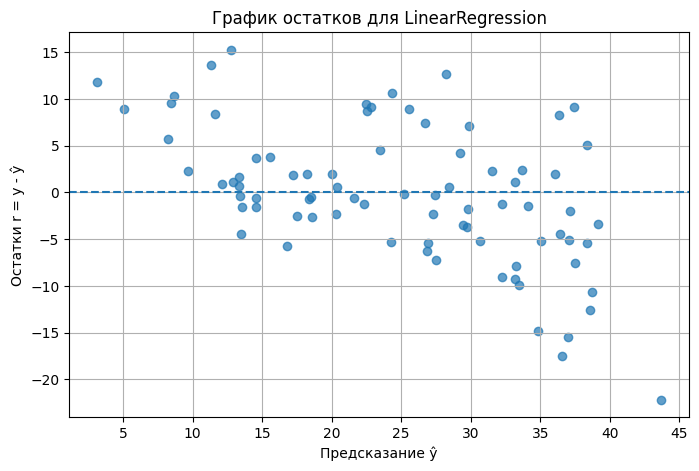

In [11]:
residuals_linear = y_val - pred_val_linear

plt.figure(figsize=(8, 5))
plt.scatter(pred_val_linear, residuals_linear, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.xlabel("Предсказание ŷ")
plt.ylabel("Остатки r = y - ŷ")
plt.title("График остатков для LinearRegression")
plt.grid(True)
plt.show()

## Анализ линейной модели

Модель `LinearRegression` использует метод наименьших квадратов, то есть минимизирует квадратичную ошибку на обучающей выборке.  
По сравнению с бейзлайнами ожидается:

- снижение MAE;
- снижение RMSE;
- увеличение R².

### Анализ графиков

**1. Диаграмма соответствия ŷ и y**  
Если модель работает хорошо, точки располагаются близко к прямой `y = x`. Чем сильнее отклонение от этой прямой, тем больше ошибка прогноза.

**2. График остатков**  
Остатки желательно видеть случайно разбросанными вокруг нуля.  
Если заметна структура, наклон, «веер» или выраженные кластеры, это может указывать на:

- нелинейность зависимости;
- гетероскедастичность;
- наличие выбросов;
- неполноту линейной модели.

In [12]:
mae_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", QuantileRegressor(
        quantile=0.5,
        alpha=0.0,
        solver="highs"
    ))
])

mae_row, pred_val_mae = evaluate_model(
    "QuantileRegressor q=0.5 (MAE)",
    mae_model,
    X_train, y_train,
    X_val, y_val
)
results.append(mae_row)

pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Baseline Mean,7.234727,8.728830,-0.025648
1,Baseline Median,7.288750,8.971817,-0.083545
2,LinearRegression (MSE / OLS),5.612800,7.295298,0.283572
3,QuantileRegressor q=0.5 (MAE),11.427253,15.252574,-2.131644


In [13]:
huber_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HuberRegressor())
])

huber_row, pred_val_huber = evaluate_model(
    "HuberRegressor",
    huber_model,
    X_train, y_train,
    X_val, y_val
)
results.append(huber_row)

metrics_table = pd.DataFrame(results)
metrics_table

,Model,MAE,RMSE,R2
0,Baseline Mean,7.234727,8.728830,-0.025648
1,Baseline Median,7.288750,8.971817,-0.083545
2,LinearRegression (MSE / OLS),5.612800,7.295298,0.283572
3,QuantileRegressor q=0.5 (MAE),11.427253,15.252574,-2.131644
4,HuberRegressor,3.009446,3.860706,0.799359


In [14]:
metrics_table.sort_values(by="MAE").reset_index(drop=True)

,Model,MAE,RMSE,R2
0,HuberRegressor,3.009446,3.860706,0.799359
1,LinearRegression (MSE / OLS),5.612800,7.295298,0.283572
2,Baseline Mean,7.234727,8.728830,-0.025648
3,Baseline Median,7.288750,8.971817,-0.083545
4,QuantileRegressor q=0.5 (MAE),11.427253,15.252574,-2.131644


## Сравнение функций потерь

Для сравнения были использованы:

- `LinearRegression` — модель, минимизирующая квадратичную ошибку;
- `QuantileRegressor(quantile=0.5)` — модель, ориентированная на минимизацию абсолютной ошибки;
- `HuberRegressor` — робастная модель, менее чувствительная к выбросам.

### Интерпретация различий

**MSE / квадратичная ошибка**
- сильнее штрафует большие ошибки;
- более чувствительна к выбросам;
- обычно стремится улучшить RMSE.

**MAE / абсолютная ошибка**
- штрафует ошибки линейно;
- устойчивее к выбросам;
- часто показывает более устойчивый результат по MAE.

**Huber loss**
- сочетает свойства MSE и MAE;
- на малых ошибках ведет себя как квадратичная функция;
- на больших ошибках снижает влияние выбросов.

In [15]:
metrics_table = metrics_table.sort_values(by="MAE").reset_index(drop=True)
metrics_table

,Model,MAE,RMSE,R2
0,HuberRegressor,3.009446,3.860706,0.799359
1,LinearRegression (MSE / OLS),5.612800,7.295298,0.283572
2,Baseline Mean,7.234727,8.728830,-0.025648
3,Baseline Median,7.288750,8.971817,-0.083545
4,QuantileRegressor q=0.5 (MAE),11.427253,15.252574,-2.131644


In [16]:
models_dict = {
    "LinearRegression (MSE / OLS)": linear_model,
    "QuantileRegressor q=0.5 (MAE)": mae_model,
    "HuberRegressor": huber_model
}

best_model_name = metrics_table.loc[0, "Model"]
best_model = models_dict.get(best_model_name)

print("Лучшая модель по MAE на validation:", best_model_name)

Лучшая модель по MAE на validation: HuberRegressor


In [17]:
best_model.fit(X_train, y_train)

pred_train_best = best_model.predict(X_train)
pred_test_best = best_model.predict(X_test)

final_metrics = pd.DataFrame([
    {
        "Split": "Train",
        **regression_metrics(y_train, pred_train_best)
    },
    {
        "Split": "Test",
        **regression_metrics(y_test, pred_test_best)
    }
])

final_metrics

,Split,MAE,RMSE,R2
0,Train,0.316503,0.987518,0.983279
1,Test,2.324135,3.011558,0.831317


In [18]:
def rmsle_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if np.any(y_true < 0) or np.any(y_pred < 0):
        return np.nan

    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

rmsle_train = rmsle_safe(y_train, pred_train_best)
rmsle_test = rmsle_safe(y_test, pred_test_best)

print("RMSLE train:", rmsle_train)
print("RMSLE test:", rmsle_test)

RMSLE train: 0.03770853682814671
RMSLE test: 0.13808880300462106


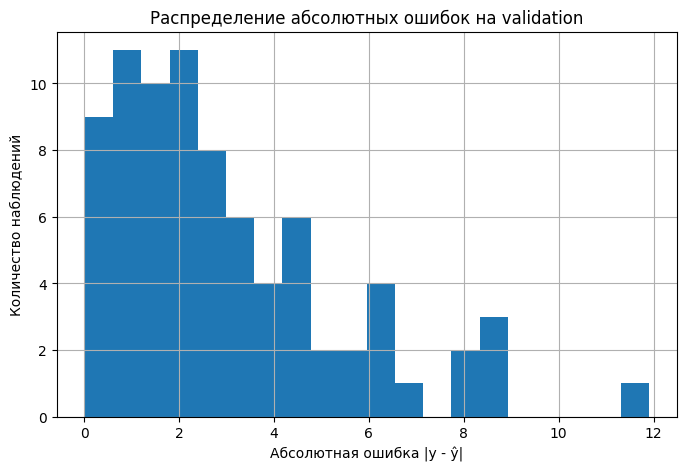

In [19]:
abs_errors = np.abs(y_val - best_model.predict(X_val))

plt.figure(figsize=(8, 5))
plt.hist(abs_errors, bins=20)
plt.xlabel("Абсолютная ошибка |y - ŷ|")
plt.ylabel("Количество наблюдений")
plt.title("Распределение абсолютных ошибок на validation")
plt.grid(True)
plt.show()

In [20]:
print("Метрики на validation:")
display(metrics_table)

print("\nМетрики лучшей модели на train/test:")
display(final_metrics)

Метрики на validation:


,Model,MAE,RMSE,R2
0,HuberRegressor,3.009446,3.860706,0.799359
1,LinearRegression (MSE / OLS),5.612800,7.295298,0.283572
2,Baseline Mean,7.234727,8.728830,-0.025648
3,Baseline Median,7.288750,8.971817,-0.083545
4,QuantileRegressor q=0.5 (MAE),11.427253,15.252574,-2.131644



Метрики лучшей модели на train/test:


,Split,MAE,RMSE,R2
0,Train,0.316503,0.987518,0.983279
1,Test,2.324135,3.011558,0.831317


# Итоговые выводы

## 1. Подготовка данных
Данные были разделены на обучающую, валидационную и тестовую выборки в соотношении 60 / 20 / 20.  
Предобработка была реализована внутри `Pipeline`, что исключает утечки данных.

## 2. Бейзлайны
Константные модели, предсказывающие среднее и медиану целевой переменной, показали наихудшее качество.  
Это ожидаемо, так как они не используют признаки объектов.

## 3. Линейная модель
`LinearRegression` показала качество лучше бейзлайнов, что подтверждает наличие связи между признаками и целевой переменной.  
Графики `ŷ` и `y`, а также график остатков позволяют визуально оценить качество модели и структуру ошибок.

## 4. Сравнение функций потерь
Сравнение моделей показало, что выбор функции потерь влияет на характер ошибок:

- модель с квадратичной ошибкой сильнее реагирует на крупные промахи;
- модель с абсолютной ошибкой обычно устойчивее к выбросам;
- Huber-модель может давать компромиссный результат.

## 5. Финальная оценка
Лучшая модель была выбрана по метрике **MAE** на validation-выборке.  
После этого она была проверена на test-выборке, которая не использовалась при обучении.

Если значения метрик на train и test близки, модель можно считать устойчивой.  
Если качество на train заметно лучше, чем на test, это может указывать на переобучение.

## 6. Обоснование выбора ключевой метрики
В качестве основной метрики выбрана **MAE**, так как она:
- измеряется в тех же единицах, что и целевая переменная;
- проще интерпретируется;
- менее чувствительна к выбросам, чем RMSE.